In [33]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [34]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: >

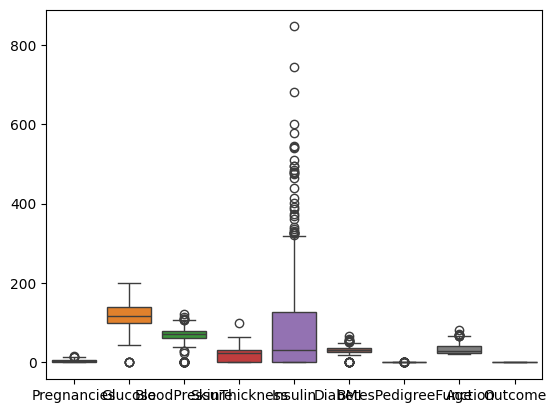

In [35]:


sns.boxplot(data=df)

In [36]:
cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for col in cols:
    print(col, (df[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [37]:
df[cols] = df[cols].replace(
    0,
    np.nan
)
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

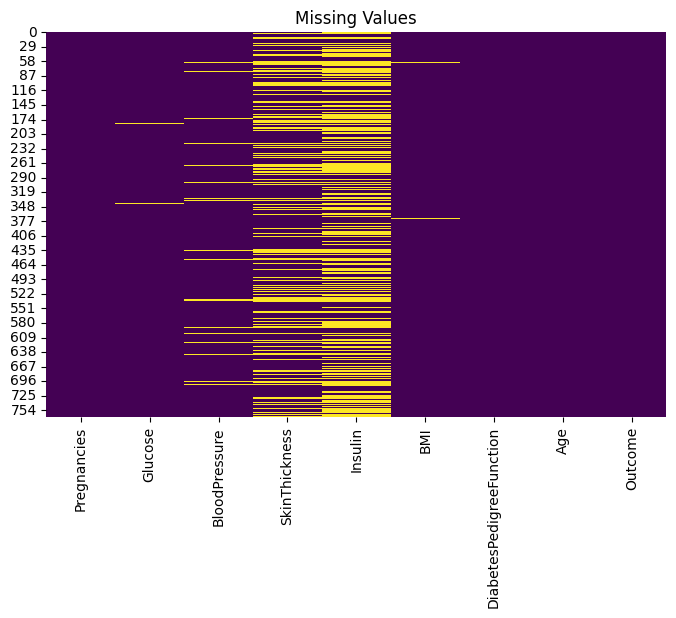

In [38]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values")
plt.show()

In [39]:
imputer = SimpleImputer(
    strategy="median"
)

df[cols] = imputer.fit_transform(
    df[cols]
)

In [40]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

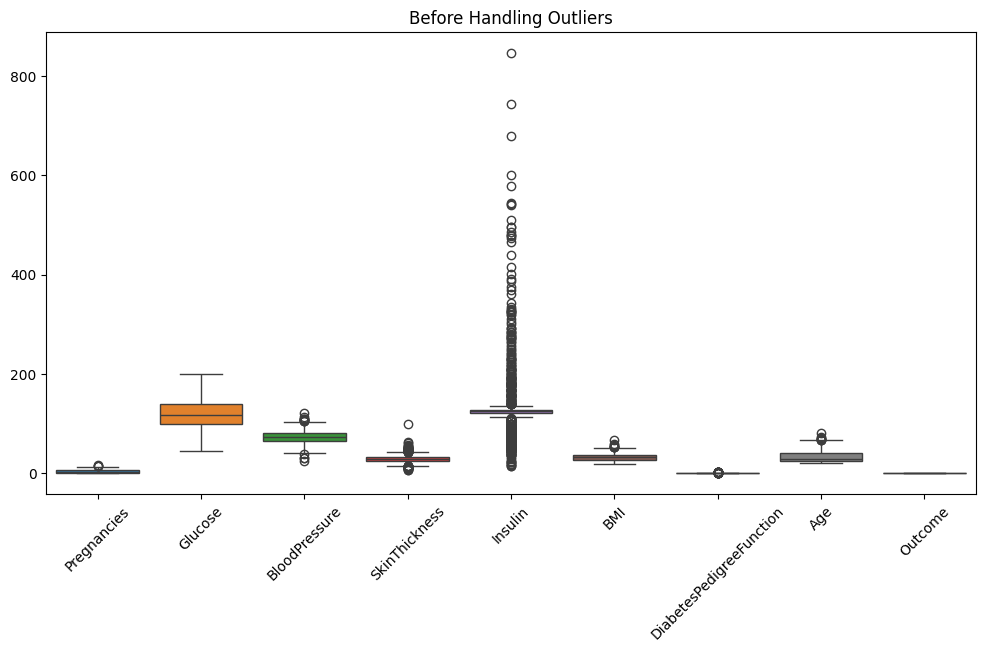

In [41]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.title("Before Handling Outliers")

plt.show()

In [42]:
def handle_outlier_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[column] = data[column].clip(
        lower,
        upper
    )

    return data

outlier_cols = [
    'Glucose',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction'
]

for col in outlier_cols:
    df = handle_outlier_iqr(df, col)    

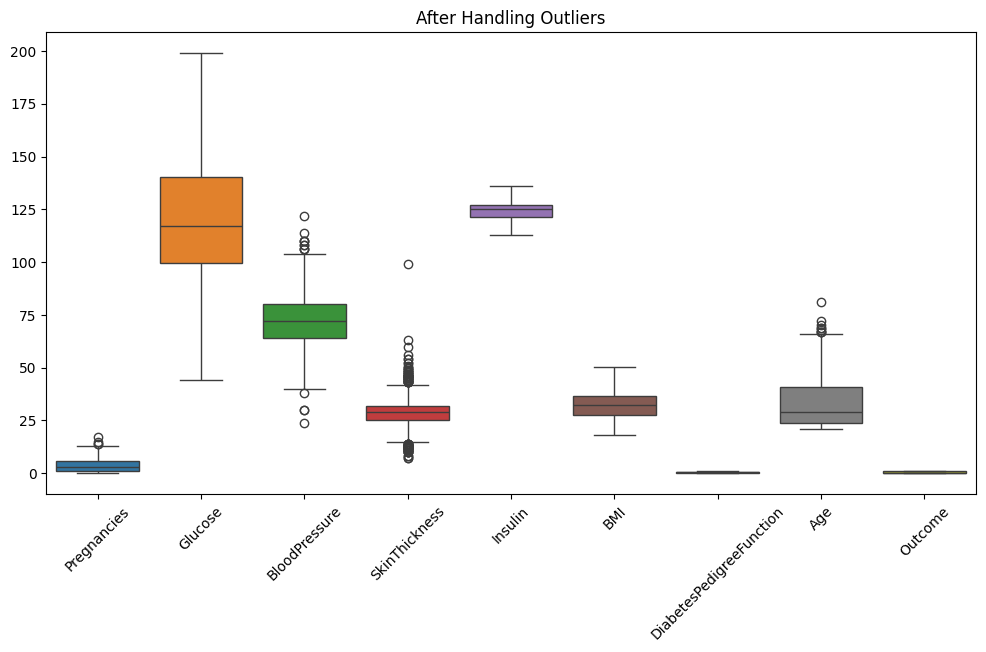

In [43]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.title("After Handling Outliers")

plt.show()

In [44]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,30,45,60,100],
    labels=[0,1,2,3]
)
df['BMI_Category'] = pd.cut(
    df['BMI'],
    bins=[0,18.5,25,30,100],
    labels=[0,1,2,3]
)
df['Glucose_BMI'] = (
    df['Glucose']
    *
    df['BMI']
)

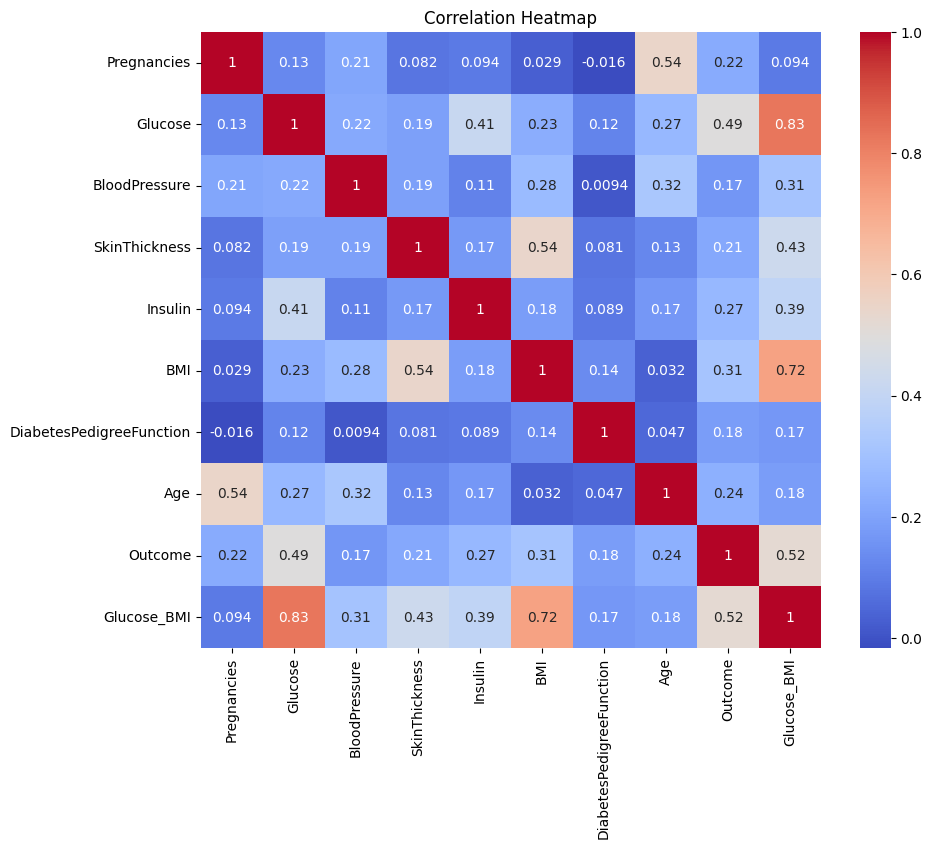

In [45]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [46]:
X = df.drop(
    "Outcome",
    axis=1
)

y = df["Outcome"]
selector = SelectKBest(
    score_func=chi2,
    k=5
)

selector.fit(X, y)
feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

feature_scores.sort_values(
    by="Score",
    ascending=False
)

,Feature,Score
10,Glucose_BMI,109860.007785
1,Glucose,1418.442397
7,Age,181.303689
0,Pregnancies,111.519691
5,BMI,102.997429
3,SkinThickness,94.025335
8,Age_Group,43.380784
2,BloodPressure,42.582507
4,Insulin,27.334810
9,BMI_Category,16.527489


In [47]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

In [48]:
df.to_csv(
    "diabetes_clean.csv",
    index=False
)
scaled_df = X_scaled.copy()

scaled_df["Outcome"] = y

scaled_df.to_csv(
    "diabetes_standardized.csv",
    index=False
)

In [49]:
import os

print("diabetes_clean.csv:",
      os.path.exists("diabetes_clean.csv"))

print("diabetes_standardized.csv:",
      os.path.exists("diabetes_standardized.csv"))

diabetes_clean.csv: True
diabetes_standardized.csv: True
